LUKOLOLA NGANDA BRUNO 26RP00283
Machine Learning

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
os.makedirs("figures", exist_ok=True)

raw = pd.read_csv("house_price_prediction_dataset.csv")
print("Shape (rows, columns):", raw.shape)

Shape (rows, columns): (125, 9)


In [2]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   House_ID                 125 non-null    int64  
 1   Area_m2                  123 non-null    float64
 2   Bedrooms                 124 non-null    float64
 3   Bathrooms                124 non-null    float64
 4   House_Age_Years          124 non-null    float64
 5   Distance_to_City_km      124 non-null    float64
 6   Parking_Spaces           124 non-null    float64
 7   Neighborhood             124 non-null    str    
 8   House_Price_Million_RWF  124 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 8.9 KB


In [3]:
raw.head()

,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
0,1001,144.6,2.0,2.0,15.0,27.40,0.0,Kigali City,104.8
1,1002,101.9,4.0,4.0,15.5,5.97,1.0,Huye,137.0
2,1003,157.1,3.0,2.0,8.9,2.42,1.0,Nyarugenge,171.6
3,1004,254.2,3.0,2.0,15.5,6.68,1.0,Musanze,197.2
4,1005,96.7,3.0,2.0,9.5,12.34,2.0,Gasabo,121.8


In [4]:
raw.describe().T

,count,mean,std,min,25%,50%,75%,max
House_ID,125.0,1059.000000,34.938887,1001.00,1028.0000,1058.000,1089.0000,1120.0
Area_m2,123.0,134.808943,133.300251,26.00,82.4500,107.900,141.0000,1200.0
Bedrooms,124.0,3.298387,1.216284,1.00,2.0000,3.000,4.0000,6.0
Bathrooms,124.0,3.016129,1.202868,1.00,2.0000,3.000,4.0000,5.0
House_Age_Years,124.0,9.773387,10.435564,0.40,3.1750,6.650,12.1250,75.0
Distance_to_City_km,124.0,5.652419,8.701097,0.07,1.5575,3.535,7.0725,85.0
Parking_Spaces,124.0,1.185484,0.849361,0.00,1.0000,1.000,2.0000,3.0
House_Price_Million_RWF,124.0,173.254032,127.372543,77.70,118.5250,150.650,186.6750,1200.0


In [5]:
missing = raw.isna().sum().to_frame("missing_count")
missing["missing_%"] = (missing["missing_count"] / len(raw) * 100).round(2)
missing

,missing_count,missing_%
House_ID,0,0.0
Area_m2,2,1.6
Bedrooms,1,0.8
Bathrooms,1,0.8
House_Age_Years,1,0.8
Distance_to_City_km,1,0.8
Parking_Spaces,1,0.8
Neighborhood,1,0.8
House_Price_Million_RWF,1,0.8


In [6]:
raw[raw.isna().any(axis=1)]

,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
7,1008,NaN,4.0,3.0,2.2,2.51,1.0,Huye,177.1
14,1015,42.6,NaN,3.0,10.3,1.55,0.0,Gasabo,112.6
22,1023,114.2,3.0,NaN,4.9,1.58,2.0,Kicukiro,185.2
31,1032,304.7,2.0,2.0,NaN,4.01,0.0,Kigali City,249.1
39,1040,122.6,5.0,5.0,6.9,NaN,2.0,Huye,213.4
51,1052,89.0,2.0,2.0,6.1,4.40,NaN,Musanze,112.4
63,1064,57.0,3.0,3.0,0.5,1.56,1.0,NaN,139.3
79,1080,36.9,1.0,1.0,7.8,11.67,1.0,Musanze,NaN
103,1104,NaN,6.0,5.0,5.8,2.09,1.0,Kicukiro,177.7


In [7]:
print("Fully duplicated rows:", raw.duplicated().sum())
print("Duplicated House_IDs :", raw.duplicated("House_ID").sum())
raw[raw.duplicated(keep=False)].sort_values("House_ID")

Fully duplicated rows: 5
Duplicated House_IDs : 5


,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
10,1011,85.3,1.0,1.0,8.7,0.93,2.0,Gasabo,99.8
120,1011,85.3,1.0,1.0,8.7,0.93,2.0,Gasabo,99.8
123,1011,85.3,1.0,1.0,8.7,0.93,2.0,Gasabo,99.8
25,1026,116.9,5.0,4.0,5.0,14.11,0.0,Huye,140.4
121,1026,116.9,5.0,4.0,5.0,14.11,0.0,Huye,140.4
124,1026,116.9,5.0,4.0,5.0,14.11,0.0,Huye,140.4
40,1041,165.1,5.0,5.0,6.2,8.84,0.0,Huye,236.2
122,1041,165.1,5.0,5.0,6.2,8.84,0.0,Huye,236.2


In [8]:
df = raw.drop_duplicates().copy()
print("Rows before:", len(raw), "| rows after removing duplicates:", len(df))

Rows before: 125 | rows after removing duplicates: 120


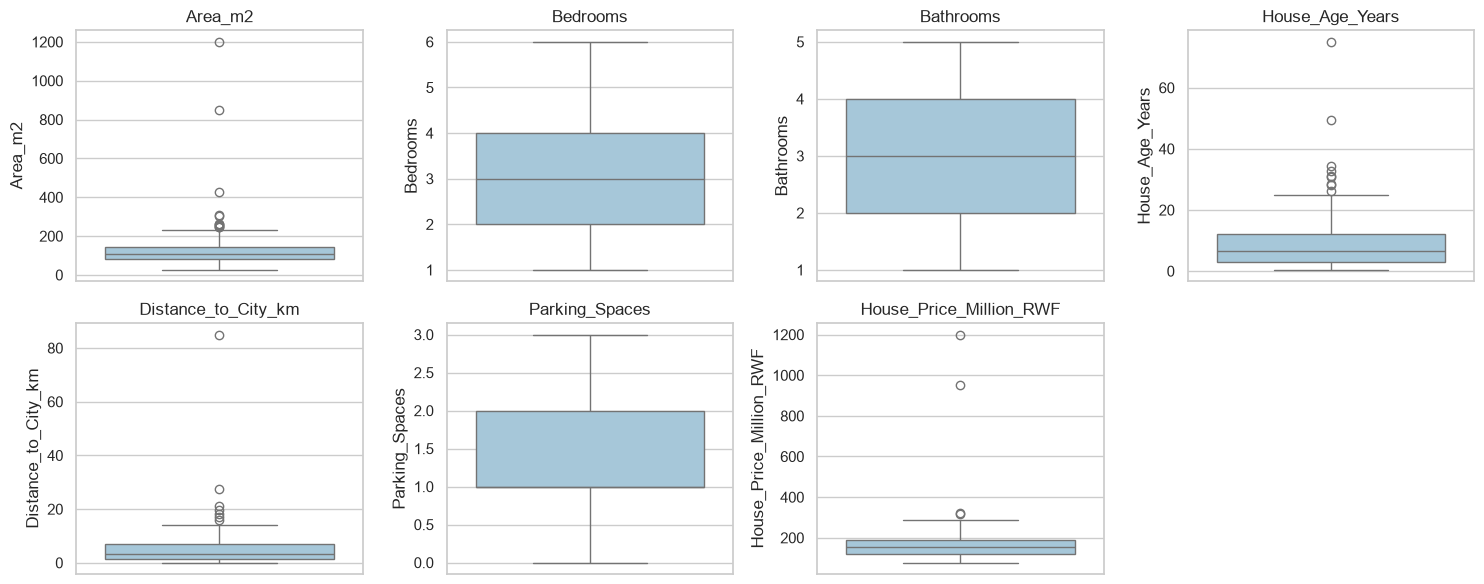

In [10]:
df = df.dropna(subset=["House_Price_Million_RWF"]).copy()      # target missing -> drop (see A2)
num_cols = ["Area_m2", "Bedrooms", "Bathrooms", "House_Age_Years",
            "Distance_to_City_km", "Parking_Spaces", "House_Price_Million_RWF"]

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, c in zip(axes.ravel(), num_cols):
    sns.boxplot(y=df[c], ax=ax, color="#9ecae1")
    ax.set_title(c)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.savefig("figures/boxplots_raw.png", dpi=130)
plt.show()

In [13]:
rows = []
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    elo, ehi = q1 - 3 * iqr, q3 + 3 * iqr
    rows.append([c, round(lo, 2), round(hi, 2),
                 int(((df[c] < lo) | (df[c] > hi)).sum()),
                 int(((df[c] < elo) | (df[c] > ehi)).sum())])
iqr_table = pd.DataFrame(rows, columns=["Variable", "Lower fence", "Upper fence", "Mild+extreme outliers", "Extreme outliers (3 IQR)"])
iqr_table

,Variable,Lower fence,Upper fence,Mild+extreme outliers,Extreme outliers (3 IQR)
0,Area_m2,-11.40,238.20,11,3
1,Bedrooms,-1.00,7.00,0,0
2,Bathrooms,-1.00,7.00,0,0
3,House_Age_Years,-11.04,26.26,9,2
4,Distance_to_City_km,-6.38,14.80,7,2
5,Parking_Spaces,-0.50,3.50,0,0
6,House_Price_Million_RWF,19.95,287.15,4,2


In [14]:
suspicious = df[(df.Area_m2 > 500) | (df.House_Price_Million_RWF > 500) |
                (df.House_Age_Years > 40) | (df.Distance_to_City_km > 40)]
suspicious

,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
5,1006,850.0,3.0,3.0,2.1,15.93,0.0,Kigali City,150.2
18,1019,1200.0,4.0,4.0,10.6,0.16,3.0,Huye,152.9
33,1034,61.5,5.0,5.0,75.0,2.65,1.0,Kigali City,179.6
47,1048,196.7,1.0,1.0,3.9,85.00,1.0,Nyarugenge,199.6
62,1063,59.9,4.0,4.0,49.5,0.24,1.0,Kicukiro,92.7
72,1073,107.9,4.0,4.0,5.0,7.85,2.0,Musanze,950.0
91,1092,187.4,4.0,4.0,3.6,3.71,1.0,Gasabo,1200.0


**Reasoning for each extreme record**

| House_ID | Value | Why it is a problem | Decision |
|---|---|---|---|
| 1006 | Area = 850 m², 3 bedrooms, price 150 | An 850 m² house with 3 bedrooms and a normal price is not credible (probably a decimal-point typing error for 85.0). The true value cannot be recovered with certainty. | **Remove row** |
| 1019 | Area = 1200 m², 4 bedrooms, price 153 | Same problem (probably 120.0). | **Remove row** |
| 1073 | Price = 950 for a 107.9 m² house | About 5x higher than any comparable house (the model-based estimate is about 165). Target error cannot be guessed. | **Remove row** |
| 1092 | Price = 1200 for a 187.4 m² house | Same problem. | **Remove row** |
| 1034 | Age = 75 years | An old house is possible, but 75 is far beyond the next largest value (49.5) and would act as a high-leverage point. | **Cap** at the upper IQR fence |
| 1063 | Age = 49.5 years | Same reason (beyond the 3 IQR fence). | **Cap** at the upper IQR fence |
| 1048 | Distance = 85 km (for a Nyarugenge house) | Nyarugenge is a central district, so 85 km is not credible, and it is far beyond the next largest value (27.4). | **Cap** at the upper IQR fence |

*Removing* is used when a value is clearly impossible and cannot be corrected (the whole record is unreliable). *Capping (winsorising)* is used when the value could be genuine but is so extreme that it would pull the regression line; capping keeps the row and its other information. Moderate outliers (for example the 426 m² house in Musanze priced at 319 million) are **kept** because their price is consistent with their size, so they are real expensive houses.

In [15]:
# 1) remove impossible / unrecoverable rows
before = len(df)
df = df[(df.Area_m2.isna() | (df.Area_m2 <= 500)) & (df.House_Price_Million_RWF <= 500)].copy()
print("Rows removed as impossible:", before - len(df))

# 2) cap extreme but possible values at the upper IQR fence (computed after step 1)
caps = {}
for c in ["House_Age_Years", "Distance_to_City_km"]:
    q1, q3 = df[c].quantile([0.25, 0.75])
    caps[c] = round(q3 + 1.5 * (q3 - q1), 2)
    n = int((df[c] > caps[c]).sum() )
    print(f"{c}: cap = {caps[c]} -> {n} values above the cap")

Rows removed as impossible: 4
House_Age_Years: cap = 27.82 -> 8 values above the cap
Distance_to_City_km: cap = 14.23 -> 6 values above the cap


Note: capping at the 1.5·IQR fence is applied **only to the extreme values identified in the table above** (age above 40 years, distance above 40 km). Mild outliers such as a 27 km distance or a 32-year-old house are plausible and are kept untouched.

In [16]:
for c in ["House_Age_Years", "Distance_to_City_km"]:
    mask = df[c] > 40
    print(f"{c}: {int(mask.sum())} extreme value(s) capped to {caps[c]}")
    df.loc[mask, c] = caps[c]

df = df.reset_index(drop=True)
print("\nFinal cleaned shape:", df.shape)
df.describe().T

House_Age_Years: 2 extreme value(s) capped to 27.82
Distance_to_City_km: 1 extreme value(s) capped to 14.23

Final cleaned shape: (115, 9)


,count,mean,std,min,25%,50%,75%,max
House_ID,115.0,1060.782609,34.762296,1001.00,1031.500,1060.00,1090.50,1120.0
Area_m2,113.0,120.617699,65.423614,26.00,81.500,105.70,135.20,426.4
Bedrooms,114.0,3.298246,1.174431,1.00,2.000,3.00,4.00,6.0
Bathrooms,114.0,3.008772,1.178687,1.00,2.000,3.00,4.00,5.0
House_Age_Years,114.0,9.476667,8.423751,0.40,2.950,6.85,12.90,34.3
Distance_to_City_km,114.0,4.841140,4.830113,0.07,1.565,3.27,6.63,27.4
Parking_Spaces,114.0,1.192982,0.829513,0.00,1.000,1.00,2.00,3.0
House_Price_Million_RWF,115.0,159.250435,51.090919,77.70,118.250,151.10,186.00,322.0


In [17]:
df.to_csv("house_price_cleaned.csv", index=False)
print("Saved house_price_cleaned.csv")

Saved house_price_cleaned.csv


The cleaned file still contains a few missing predictor values on purpose; they are imputed inside the pipeline (see A2) so that no information from the test set leaks into training.

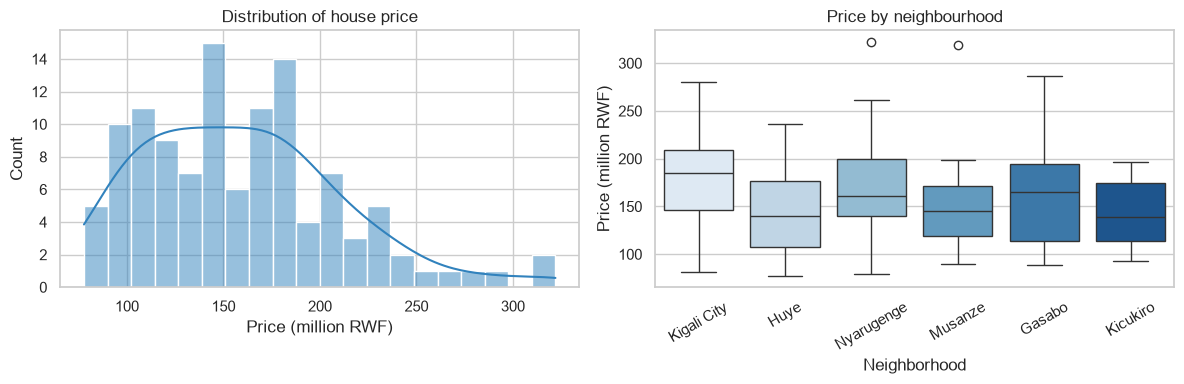

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.House_Price_Million_RWF, kde=True, bins=20, ax=ax[0], color="#3182bd")
ax[0].set_title("Distribution of house price"); ax[0].set_xlabel("Price (million RWF)")
sns.boxplot(data=df, y="House_Price_Million_RWF", x="Neighborhood", ax=ax[1], palette="Blues")
ax[1].set_title("Price by neighbourhood"); ax[1].tick_params(axis="x", rotation=30)
ax[1].set_ylabel("Price (million RWF)")
plt.tight_layout(); plt.savefig("figures/price_dist_and_neigh.png", dpi=130); plt.show()

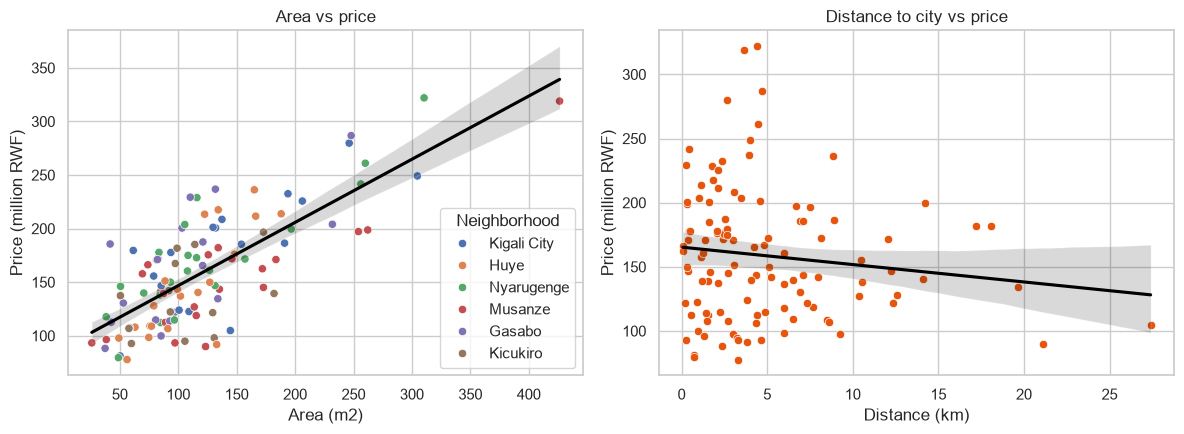

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=df, x="Area_m2", y="House_Price_Million_RWF", hue="Neighborhood", ax=ax[0])
sns.regplot(data=df, x="Area_m2", y="House_Price_Million_RWF", scatter=False, color="black", ax=ax[0])
ax[0].set_title("Area vs price"); ax[0].set_xlabel("Area (m2)"); ax[0].set_ylabel("Price (million RWF)")
sns.scatterplot(data=df, x="Distance_to_City_km", y="House_Price_Million_RWF", ax=ax[1], color="#e6550d")
sns.regplot(data=df, x="Distance_to_City_km", y="House_Price_Million_RWF", scatter=False, color="black", ax=ax[1])
ax[1].set_title("Distance to city vs price"); ax[1].set_xlabel("Distance (km)"); ax[1].set_ylabel("Price (million RWF)")
plt.tight_layout(); plt.savefig("figures/scatter_area_distance.png", dpi=130); plt.show()

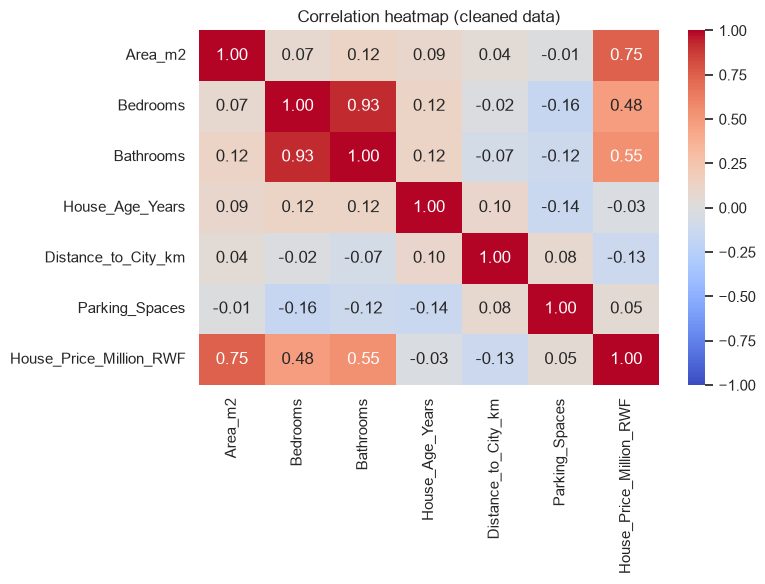

In [20]:
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation heatmap (cleaned data)")
plt.tight_layout(); plt.savefig("figures/heatmap.png", dpi=130); plt.show()

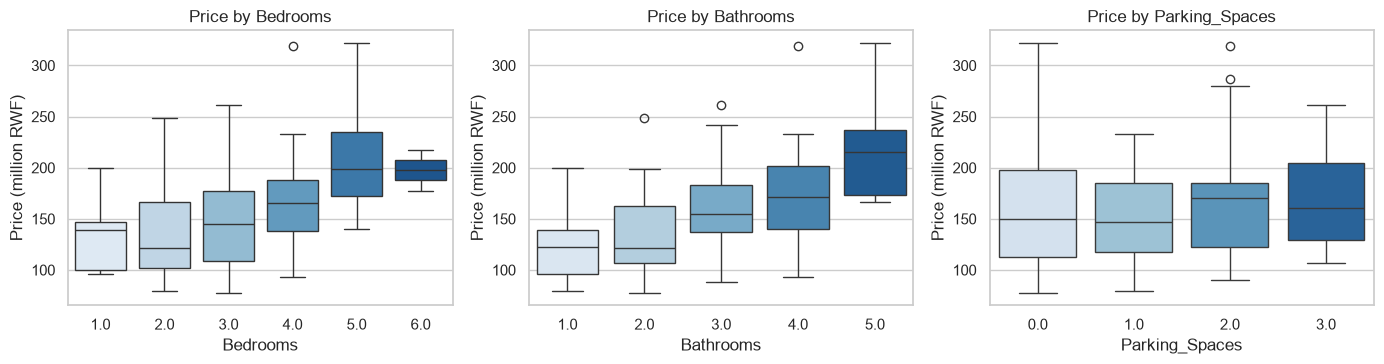

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for a, c in zip(ax, ["Bedrooms", "Bathrooms", "Parking_Spaces"]):
    sns.boxplot(data=df, x=c, y="House_Price_Million_RWF", ax=a, palette="Blues")
    a.set_title(f"Price by {c}"); a.set_ylabel("Price (million RWF)")
plt.tight_layout(); plt.savefig("figures/price_by_counts.png", dpi=130); plt.show()

In [22]:
log = pd.DataFrame([
 ["Duplicate records", "5 identical rows at the end of the file (IDs 1011, 1026, 1041, 1011, 1026)", "Removed (kept first copy)", "Copies over-weight some houses and leak between train and test sets"],
 ["Missing target", "House_Price_Million_RWF, 1 row (ID 1080)", "Row dropped", "A target value must not be invented"],
 ["Missing numeric predictors", "Area (2), Bedrooms, Bathrooms, Age, Distance, Parking (1 each)", "Median imputation inside the Pipeline", "Keeps rows in a tiny dataset; median is robust to outliers; fitted on train only"],
 ["Missing category", "Neighborhood, 1 row (ID 1064)", "Most-frequent imputation inside the Pipeline", "Only one row; mode is the simplest safe choice"],
 ["Impossible area", "Area_m2 = 850 and 1200 (IDs 1006, 1019)", "Rows removed", "Not credible for 3 to 4 bedroom houses; true value unknown"],
 ["Impossible price", "Price = 950 and 1200 (IDs 1073, 1092)", "Rows removed", "About 5x above comparable houses; target error cannot be corrected"],
 ["Extreme age", "House_Age_Years = 75 and 49.5 (IDs 1034, 1063)", "Capped at upper IQR fence", "Possible but high-leverage points"],
 ["Extreme distance", "Distance_to_City_km = 85 (ID 1048, central district)", "Capped at upper IQR fence", "Not credible for Nyarugenge; keeps other info of the row"],
 ["Wrong data types", "Bedrooms, Bathrooms, Parking stored as float", "Left as numeric (whole numbers)", "Float only because of NaN; no effect on the model"],
 ["Text category", "Neighborhood (6 levels)", "One-hot encoded (drop first)", "Linear regression needs numeric inputs; dropping one level avoids the dummy-variable trap"],
 ["Identifier", "House_ID", "Excluded from the predictors", "It is a label, not a feature"],
], columns=["Problem found", "Where", "Action taken", "Reason"])
log.to_csv("figures/cleaning_log.csv", index=False)
pd.set_option("display.max_colwidth", 120)
log

,Problem found,Where,Action taken,Reason
0,Duplicate records,"5 identical rows at the end of the file (IDs 1011, 1026, 1041, 1011, 1026)",Removed (kept first copy),Copies over-weight some houses and leak between train and test sets
1,Missing target,"House_Price_Million_RWF, 1 row (ID 1080)",Row dropped,A target value must not be invented
2,Missing numeric predictors,"Area (2), Bedrooms, Bathrooms, Age, Distance, Parking (1 each)",Median imputation inside the Pipeline,Keeps rows in a tiny dataset; median is robust to outliers; fitted on train only
3,Missing category,"Neighborhood, 1 row (ID 1064)",Most-frequent imputation inside the Pipeline,Only one row; mode is the simplest safe choice
4,Impossible area,"Area_m2 = 850 and 1200 (IDs 1006, 1019)",Rows removed,Not credible for 3 to 4 bedroom houses; true value unknown
5,Impossible price,"Price = 950 and 1200 (IDs 1073, 1092)",Rows removed,About 5x above comparable houses; target error cannot be corrected
6,Extreme age,"House_Age_Years = 75 and 49.5 (IDs 1034, 1063)",Capped at upper IQR fence,Possible but high-leverage points
7,Extreme distance,"Distance_to_City_km = 85 (ID 1048, central district)",Capped at upper IQR fence,Not credible for Nyarugenge; keeps other info of the row
8,Wrong data types,"Bedrooms, Bathrooms, Parking stored as float",Left as numeric (whole numbers),Float only because of NaN; no effect on the model
9,Text category,Neighborhood (6 levels),One-hot encoded (drop first),Linear regression needs numeric inputs; dropping one level avoids the dummy-variable trap


In [23]:
target = "House_Price_Million_RWF"
numeric_features = ["Area_m2", "Bedrooms", "Bathrooms", "House_Age_Years", "Distance_to_City_km", "Parking_Spaces"]
categorical_features = ["Neighborhood"]
feature_cols = numeric_features + categorical_features      # House_ID and the target are excluded

X = df[feature_cols]
y = df[target]
print("X shape:", X.shape, "| y shape:", y.shape)
X.head()

X shape: (115, 7) | y shape: (115,)


,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood
0,144.6,2.0,2.0,15.0,27.40,0.0,Kigali City
1,101.9,4.0,4.0,15.5,5.97,1.0,Huye
2,157.1,3.0,2.0,8.9,2.42,1.0,Nyarugenge
3,254.2,3.0,2.0,15.5,6.68,1.0,Musanze
4,96.7,3.0,2.0,9.5,12.34,2.0,Gasabo


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (92, 7) | Test: (23, 7)


In [25]:
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first")),          # drop one level -> no dummy-variable trap
    ]), categorical_features),
])

model = Pipeline([
    ("preprocess", preprocess),
    ("regressor", LinearRegression()),
])
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


`OneHotEncoder(drop="first")` removes the first category alphabetically (**Gasabo**), so Gasabo is the *reference* neighbourhood and each neighbourhood coefficient measures the price difference compared with Gasabo.

In [26]:
feature_names = (numeric_features +
                 list(model.named_steps["preprocess"].named_transformers_["cat"]
                      .named_steps["onehot"].get_feature_names_out(categorical_features)))
coef_table = pd.DataFrame({"Variable": feature_names,
                           "Coefficient": model.named_steps["regressor"].coef_}).round(4)
print("Intercept:", round(model.named_steps["regressor"].intercept_, 4))
coef_table.to_csv("figures/coefficients.csv", index=False)
coef_table

Intercept: 31.4298


,Variable,Coefficient
0,Area_m2,0.5489
1,Bedrooms,6.3151
2,Bathrooms,16.6367
3,House_Age_Years,-0.8026
4,Distance_to_City_km,-0.8581
5,Parking_Spaces,6.0075
6,Neighborhood_Huye,-15.3979
7,Neighborhood_Kicukiro,-14.2269
8,Neighborhood_Kigali City,12.7879
9,Neighborhood_Musanze,-18.6166


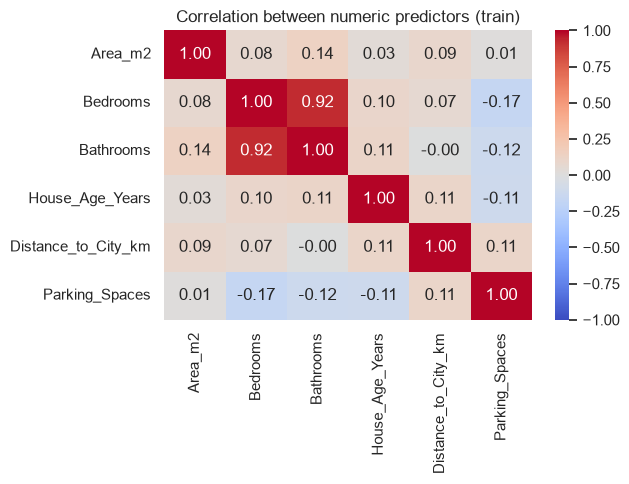

,Variable,VIF
0,Area_m2,1.12
1,Bedrooms,7.73
2,Bathrooms,7.89
3,House_Age_Years,1.11
4,Distance_to_City_km,1.15
5,Parking_Spaces,1.17
6,Neighborhood_Huye,2.00
7,Neighborhood_Kicukiro,1.71
8,Neighborhood_Kigali City,1.75
9,Neighborhood_Musanze,1.87


In [27]:
Xp = pd.DataFrame(model.named_steps["preprocess"].transform(X_train).astype(float), columns=feature_names)

# pairwise correlation of numeric predictors
plt.figure(figsize=(6.5, 5))
sns.heatmap(Xp[numeric_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between numeric predictors (train)")
plt.tight_layout(); plt.savefig("figures/predictor_corr.png", dpi=130); plt.show()

# Variance Inflation Factor: VIF_j = 1 / (1 - R2_j), R2_j from regressing predictor j on all the others
def vif_table(frame):
    out = []
    for c in frame.columns:
        others = frame.drop(columns=c)
        r2 = LinearRegression().fit(others, frame[c]).score(others, frame[c])
        out.append([c, round(1 / (1 - r2), 2)])
    return pd.DataFrame(out, columns=["Variable", "VIF"])

vif = vif_table(Xp)
vif.to_csv("figures/vif.csv", index=False)
vif

In [28]:
print("Correlation Bedrooms vs Bathrooms:", round(Xp["Bedrooms"].corr(Xp["Bathrooms"]), 3))

Correlation Bedrooms vs Bathrooms: 0.923


In [29]:
def adj_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

p = len(feature_names)     # number of predictors after encoding
rows = []
for name, Xs, ys in [("Training", X_train, y_train), ("Test", X_test, y_test)]:
    pred = model.predict(Xs)
    r2 = r2_score(ys, pred)
    rows.append([name, len(ys), r2, adj_r2(r2, len(ys), p),
                 mean_absolute_error(ys, pred), np.sqrt(mean_squared_error(ys, pred))])
metrics = pd.DataFrame(rows, columns=["Set", "n", "R2", "Adjusted R2", "MAE (M RWF)", "RMSE (M RWF)"]).round(3)
metrics.to_csv("figures/metrics.csv", index=False)
metrics

,Set,n,R2,Adjusted R2,MAE (M RWF),RMSE (M RWF)
0,Training,92,0.875,0.858,14.657,17.775
1,Test,23,0.784,0.568,18.989,23.938


In [30]:
from sklearn.model_selection import cross_val_score, KFold
cv = cross_val_score(model, X, y, cv=KFold(5, shuffle=True, random_state=42), scoring="r2")
print("5-fold cross-validated R2:", cv.round(3), "| mean =", cv.mean().round(3))

5-fold cross-validated R2: [0.784 0.854 0.7   0.695 0.925] | mean = 0.791


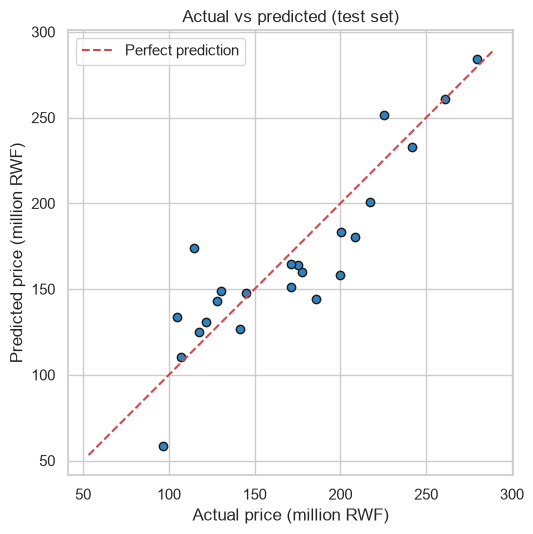

In [31]:
pred_test = model.predict(X_test)
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test, pred_test, color="#3182bd", edgecolor="k")
lims = [min(y_test.min(), pred_test.min()) - 5, max(y_test.max(), pred_test.max()) + 5]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual price (million RWF)"); plt.ylabel("Predicted price (million RWF)")
plt.title("Actual vs predicted (test set)"); plt.legend()
plt.tight_layout(); plt.savefig("figures/actual_vs_pred.png", dpi=130); plt.show()

**Interpretation:** The points follow the red diagonal reasonably closely, so the model captures the main price pattern; a handful of houses are missed by roughly 40 to 60 million RWF (see the residual plot), but the errors show no obvious pattern with price.

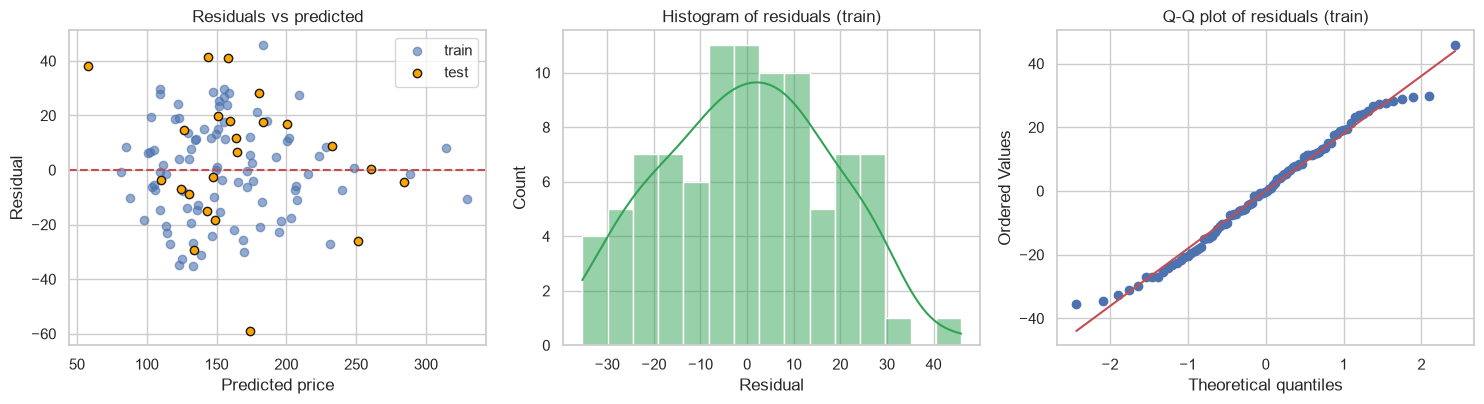

In [32]:
resid_test = y_test - pred_test
resid_train = y_train - model.predict(X_train)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].scatter(model.predict(X_train), resid_train, alpha=.6, label="train")
ax[0].scatter(pred_test, resid_test, color="orange", edgecolor="k", label="test")
ax[0].axhline(0, color="r", ls="--"); ax[0].legend()
ax[0].set_xlabel("Predicted price"); ax[0].set_ylabel("Residual"); ax[0].set_title("Residuals vs predicted")
sns.histplot(resid_train, kde=True, ax=ax[1], bins=15, color="#31a354")
ax[1].set_title("Histogram of residuals (train)"); ax[1].set_xlabel("Residual")
stats.probplot(resid_train, dist="norm", plot=ax[2]); ax[2].set_title("Q-Q plot of residuals (train)")
plt.tight_layout(); plt.savefig("figures/residuals.png", dpi=130); plt.show()

In [33]:
sh = stats.shapiro(resid_train)
print(f"Shapiro-Wilk test on training residuals: W = {sh.statistic:.3f}, p = {sh.pvalue:.4f}")

# Simple Breusch-Pagan style test for constant variance:
# regress squared residuals on the predictors; LM = n * R2 ~ chi-square(p)
e2 = resid_train.values ** 2
aux = LinearRegression().fit(Xp, e2)
lm = len(e2) * aux.score(Xp, e2)
bp_p = 1 - stats.chi2.cdf(lm, df=Xp.shape[1])
print(f"Breusch-Pagan LM = {lm:.2f}, p = {bp_p:.4f}")

# Independence: Durbin-Watson on training residuals (houses are not in time order, so this is only indicative)
r = resid_train.values
dw = np.sum(np.diff(r) ** 2) / np.sum(r ** 2)
print(f"Durbin-Watson = {dw:.2f} (about 2 means no autocorrelation)")

Shapiro-Wilk test on training residuals: W = 0.986, p = 0.4044
Breusch-Pagan LM = 8.06, p = 0.7080
Durbin-Watson = 2.10 (about 2 means no autocorrelation)


In [34]:
b = coef_table.set_index("Variable")["Coefficient"]
print(f"Area_m2              : {b['Area_m2']:.3f}  million RWF per extra m2")
print(f"Parking_Spaces       : {b['Parking_Spaces']:.3f}  million RWF per extra parking space")
print(f"House_Age_Years      : {b['House_Age_Years']:.3f}  million RWF per extra year of age")
print(f"Distance_to_City_km  : {b['Distance_to_City_km']:.3f}  million RWF per extra km from the centre")
print(f"Bathrooms            : {b['Bathrooms']:.3f}  |  Bedrooms: {b['Bedrooms']:.3f}")
print("Neighbourhoods (vs Gasabo):", {k.replace('Neighborhood_', ''): round(v, 2) for k, v in b.items() if k.startswith('Neighborhood_')})

Area_m2              : 0.549  million RWF per extra m2
Parking_Spaces       : 6.008  million RWF per extra parking space
House_Age_Years      : -0.803  million RWF per extra year of age
Distance_to_City_km  : -0.858  million RWF per extra km from the centre
Bathrooms            : 16.637  |  Bedrooms: 6.315
Neighbourhoods (vs Gasabo): {'Huye': -15.4, 'Kicukiro': -14.23, 'Kigali City': 12.79, 'Musanze': -18.62, 'Nyarugenge': 5.39}


In [35]:
joblib.dump(model, "house_price_model.sav")
print("Saved:", os.path.getsize("house_price_model.sav") / 1024, "KB")

Saved: 4.025390625 KB


In [36]:
loaded_model = joblib.load("house_price_model.sav")
original_pred = model.predict(X_test)
loaded_pred = loaded_model.predict(X_test)
print("Identical predictions:", np.array_equal(original_pred, loaded_pred))
print("Max absolute difference:", np.abs(original_pred - loaded_pred).max())

Identical predictions: True
Max absolute difference: 0.0


In [37]:
new_house = pd.DataFrame([{
    "Area_m2": 120.0, "Bedrooms": 3, "Bathrooms": 2, "House_Age_Years": 5.0,
    "Distance_to_City_km": 4.0, "Parking_Spaces": 1, "Neighborhood": "Kicukiro"}])
price = loaded_model.predict(new_house)[0]
print(f"Predicted price: {price:.1f} million RWF  (about {price * 1_000_000:,.0f} RWF)")

Predicted price: 133.9 million RWF  (about 133,854,245 RWF)


In [38]:
# training ranges, used by the Streamlit app for sensible widget limits and warnings
ranges = {c: (float(df[c].min()), float(df[c].max()), float(df[c].median())) for c in numeric_features}
ranges

{'Area_m2': (26.0, 426.4, 105.7),
 'Bedrooms': (1.0, 6.0, 3.0),
 'Bathrooms': (1.0, 5.0, 3.0),
 'House_Age_Years': (0.4, 34.3, 6.85),
 'Distance_to_City_km': (0.07, 27.4, 3.27),
 'Parking_Spaces': (0.0, 3.0, 1.0)}